In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
## Generate Synthetic Data
n_samples = 100
base_dist = dist.MultivariateNormal(
    loc=torch.Tensor([1, 4]), 
    covariance_matrix=torch.eye(2)
)

samples = base_dist.sample((100,))

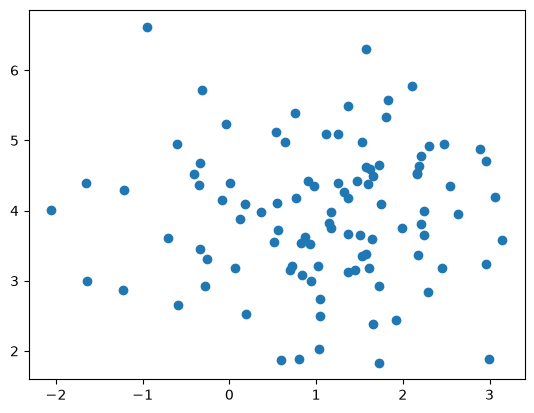

In [12]:
## plot samples
to_plot = samples.numpy()
plt.scatter(to_plot[:,0], to_plot[:,1])

## Metropolis Monte-Carlo Sampling

In [ ]:
## need a prior p(\theta) (let's choose N(0,1))
## need a distribution type for p(y|\theta) (normal dist)
## need a distribution for the jump distribution - N(0, 1/5)
prior_dist = dist.MultivariateNormal(
    loc = torch.Tensor([0, 0]),
    covariance_matrix=torch.eye(2)
)

initial_means = prior_dist.sample((1,))
print(initial_means)

jumping_dist = dist.MultivariateNormal(
    loc = initial_means,
    covariance_matrix=torch.eye(2)
)

next_means = jumping_dist.sample((1,))

print(next_means)

## calculate p(y | next_means)
## log (p(next_means)) + sum(log(p(y | next_means)))
initial_prior_logprob = prior_dist.log_prob(initial_means)
next_prior_logprob = prior_dist.log_prob(next_means)

initial_likelihood_dist = dist.MultivariateNormal(loc = initial_means,covariance_matrix=torch.eye(2))
initial_likelihood_logprob = initial_likelihood_dist.log_prob(samples)

next_likelihood_dist = dist.MultivariateNormal(loc = next_means, covariance_matrix=torch.eye(2))
next_likelihood_logprob = next_likelihood_dist.log_prob(samples)

next_p = next_prior_logprob + next_likelihood_logprob.sum()
initial_p = initial_prior_logprob + initial_likelihood_logprob.sum()
r = next_prior_logprob + next_likelihood_logprob.sum() - (initial_prior_logprob + initial_likelihood_logprob.sum())
if r >= torch.log(dist.Uniform(0, 1).sample((1,))):
    

tensor([[-1.5051,  0.0778]])
tensor([[[-1.6239,  0.1508]]])


tensor([[False]])

In [52]:
def sample_proposal_params(
        current_params: torch.Tensor,
        scale_value: float = .2
    ) -> torch.Tensor:
    return dist.MultivariateNormal(
        loc=current_params,
        covariance_matrix=scale_value * torch.eye(2)
    ).sample((1,)).squeeze()

def calc_loglik(
        samples: torch.Tensor, 
        params: torch.Tensor,
        prior_dist: dist.Distribution,
    ) -> torch.Tensor:
    loglikelihood_dist = dist.MultivariateNormal(loc=params, covariance_matrix=torch.eye(2))
    return prior_dist.log_prob(params) + loglikelihood_dist.log_prob(samples).sum()

def calc_r(
        proposal_loglik: torch.Tensor,
        current_loglik: torch.Tensor
    ) -> torch.Tensor:
    return proposal_loglik - current_loglik

def choose_next_params(
        proposal_params: torch.Tensor,
        current_params: torch.Tensor,
        r: torch.Tensor
    ) -> torch.Tensor:
    unif_sample = torch.log(dist.Uniform(0, 1).sample((1,)))
    if r >= unif_sample:
        next_params = proposal_params
    else:
        next_params = current_params
    return next_params


In [ ]:
## algo setup
num_iters = 100
num_chains = 4

## prior distribution
prior_dist = dist.MultivariateNormal(
    loc = torch.Tensor([0, 0]),
    covariance_matrix=torch.eye(2)
)

param_history = torch.empty((num_chains, num_iters + 1, 2))
for chain in range(num_chains):
    current_params = prior_dist.sample((1,)).squeeze()
    param_history[chain, 0, :] = current_params
    for t in range(num_iters):

        proposal_params = sample_proposal_params(
            current_params=current_params
        )
        proposal_loglik = calc_loglik(
            samples = samples,
            params = proposal_params,
            prior_dist=prior_dist
        )
        current_loglik = calc_loglik(
            samples = samples,
            params = current_params,
            prior_dist = prior_dist
        )
                
        r = calc_r(
            proposal_loglik=proposal_loglik, 
            current_loglik=current_loglik
        )

        # set current params to next params
        current_params = choose_next_params(
            proposal_params=proposal_params,
            current_params=current_params,
            r=r
        )
        param_history[chain, t+1, :] = current_params



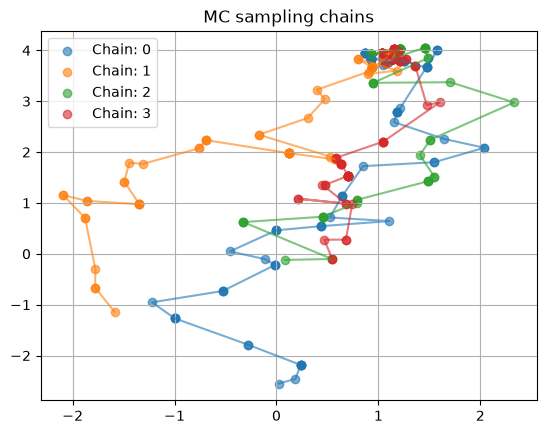

In [72]:
for c in range(num_chains):
    to_plot = param_history[c, :, :].numpy()
    plt.plot(to_plot[:, 0], to_plot[:, 1], alpha = .6)
    plt.scatter(to_plot[:, 0], to_plot[:, 1], label = f"Chain: {c}", alpha = .6)
    plt.grid(True)

plt.title("MC sampling chains")
plt.legend()
plt.show();

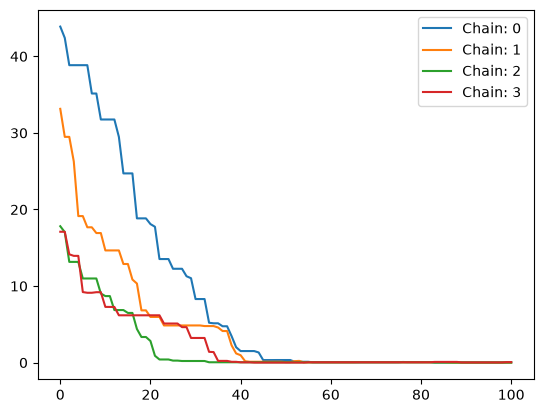

In [ ]:
for c in range(num_chains):
    to_plot = param_history[c, :, :].numpy()
    error = ((to_plot - torch.Tensor([1,4]).numpy())**2).sum(axis=1)
    plt.plot(error, label = f"Chain: {c}")

plt.legend()
plt.show();